<a href="https://colab.research.google.com/github/sujeet-banerjee/colab-genai-scratch/blob/sujeet-banerjee-patch-1/Linear_Regression_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load data

In [2]:
import pandas as pd

#pd.read_csv('/content/sample_data/california_housing_train.csv')
data = pd.read_csv(
    'https://raw.githubusercontent.com/sujeet-banerjee/colab-genai-scratch/bce40a46ce05916d6112895982a13c24aff5e95d/sample_data/linear_regression_test.csv'
       )


print(data.head())
print()
print("Dataframe shape:", data.shape)
rows = data.shape[0]
print("Rows: ", rows)

# ALL the F***-ing attribs and meth0ds!
# print(data.keys)
# print(data.columns)
# print(data.to_records)
# print(data.values)


num_features = 3
num_out = 2


   Feature_1  Feature_2  Feature_3   Target_1   Target_2
0   3.745401   9.507143   7.319939  14.792041  18.103216
1   5.986585   1.560186   1.559945  17.699507   9.022925
2   0.580836   8.661761   6.011150   7.565117  13.235299
3   7.080726   0.205845   9.699099  29.739990  -9.141942
4   8.324426   2.123391   1.818250  22.055544  14.327304

Dataframe shape: (200, 5)
Rows:  200


In [57]:
from numpy import shape
import torch

print("Targets: \n", data[['Target_1', 'Target_2']].head())

# # Column vectors as tensors!
Y_true = torch.tensor(
    data[['Target_1', 'Target_2']].
    values.reshape((rows, num_out)))

#print(f"True valyes: Y_true={Y_true}\n")

X_data = data[['Feature_1', 'Feature_2', 'Feature_3']]
print("\nFeature Set: \n", X_data.head())

X = torch.tensor(
    X_data.values.reshape(rows, num_features),
    requires_grad=True)



Targets: 
     Target_1   Target_2
0  14.792041  18.103216
1  17.699507   9.022925
2   7.565117  13.235299
3  29.739990  -9.141942
4  22.055544  14.327304

Feature Set: 
    Feature_1  Feature_2  Feature_3
0   3.745401   9.507143   7.319939
1   5.986585   1.560186   1.559945
2   0.580836   8.661761   6.011150
3   7.080726   0.205845   9.699099
4   8.324426   2.123391   1.818250


In [65]:
W = torch.randn(
    size=(num_features, num_out),
    dtype=torch.float64,
    requires_grad=True)
b = torch.randn(
    num_out, requires_grad=True
    )

print(f"W=\n{W}")
print(f"b=\n{b}")

# print("There is no .head for tensors!!!")
# print(b)
# print((X @ W)[[0,1,2,3]])
# print((X @ W + b)[[0,1,2,3]])


W=
tensor([[ 0.4073, -0.4625],
        [-1.0075, -1.5371],
        [-0.3071, -0.2247]], dtype=torch.float64, requires_grad=True)
b=
tensor([-0.2204, -0.1611], requires_grad=True)


In [73]:
import numpy as np

# DONT make the lraning rate high. Keep it 0.01 max
itr, lrn = 10000, 0.01

for epoch in range(itr):
  Y_hat = X @ W + b

  loss = torch.sqrt(torch.mean((Y_true-Y_hat)**2))
  #loss = ((Y_true - Y_hat)**2).mean()
  loss.backward(retain_graph=True, create_graph=True
                )

  if epoch % 10 == 0:
    print(f"\n\nEpoch={epoch} ; \nW.grad=\n{W.grad}, \nb.grad=\n{b.grad} |  \nLoss = {loss}")
    print(f">>>>> W=\n{W}, \n>>>>> b=\n{b} ")

  with torch.no_grad():
    # some silly error will misguide you, if you forgot requires_grad = True
    # Python mean, no clear error message! So, you keep breakin your head!
    W -= lrn * W.grad
    b -= lrn * b.grad

    # If you move this block out of 'no_grad'
    # RuntimeError: a leaf Variable that requires grad
    # is being used in an in-place operation.

    # That USUALLY is the most F***King error one would do...
    # Bloody making that freaking W AN B both ZEORRRRO
    # W.zero_()
    # b.zero_()

    # MAKE THE FU**ER GRADS ZERO... NOT THE WEIGHTS AND BIASES!
    W.grad.zero_()
    b.grad.zero_()



Streaming output truncated to the last 5000 lines.
>>>>> b=
tensor([ 4.7350, -0.8423], requires_grad=True) 


Epoch=7060 ; 
W.grad=
tensor([[ 2.0928e-14, -8.8367e-15],
        [-1.5266e-15,  1.6716e-14],
        [ 2.5535e-15,  1.5488e-14]], dtype=torch.float64,
       grad_fn=<AddBackward0>), 
b.grad=
tensor([-2.3794e-05,  2.9787e-06], grad_fn=<AddBackward0>) |  
Loss = 0.48559246650632454
>>>>> W=
tensor([[ 2.0256,  1.5053],
        [-0.4966,  2.9838],
        [ 1.0218, -2.0222]], dtype=torch.float64, requires_grad=True), 
>>>>> b=
tensor([ 4.7350, -0.8423], requires_grad=True) 


Epoch=7070 ; 
W.grad=
tensor([[ 2.0928e-14, -8.8367e-15],
        [-1.5266e-15,  1.6716e-14],
        [ 2.5535e-15,  1.5488e-14]], dtype=torch.float64,
       grad_fn=<AddBackward0>), 
b.grad=
tensor([-2.3794e-05,  2.9787e-06], grad_fn=<AddBackward0>) |  
Loss = 0.48559246650632454
>>>>> W=
tensor([[ 2.0256,  1.5053],
        [-0.4966,  2.9838],
        [ 1.0218, -2.0222]], dtype=torch.float64, requires_grad

In [68]:
rmse_final = ((Y_hat.detach() - Y_true.detach())**2).mean().sqrt()
print("RMSE FINAL= ", rmse_final)

RMSE FINAL=  tensor(4.6991, dtype=torch.float64)


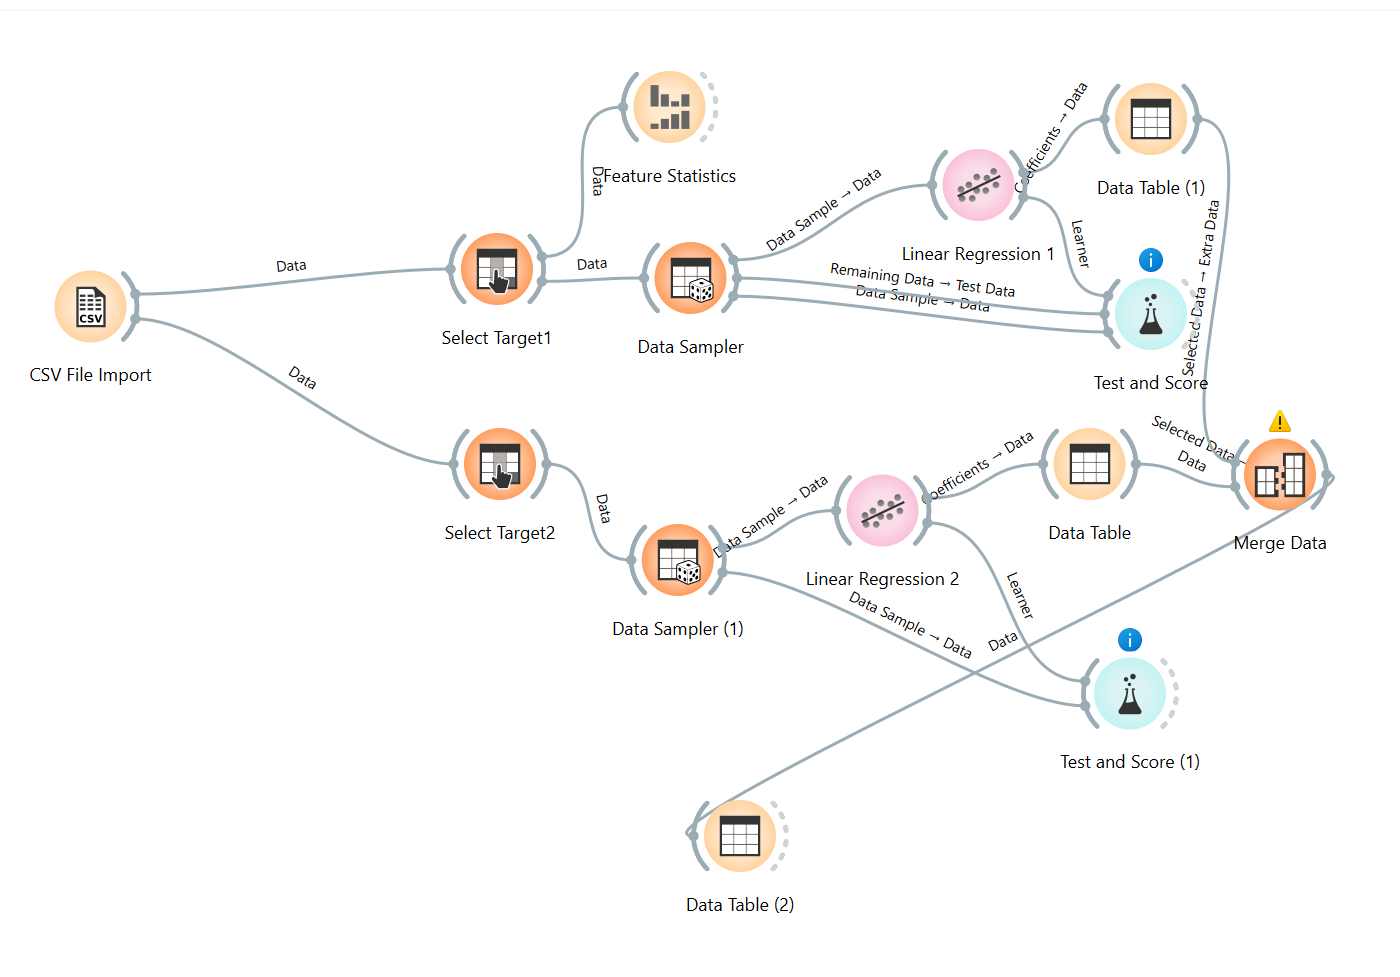

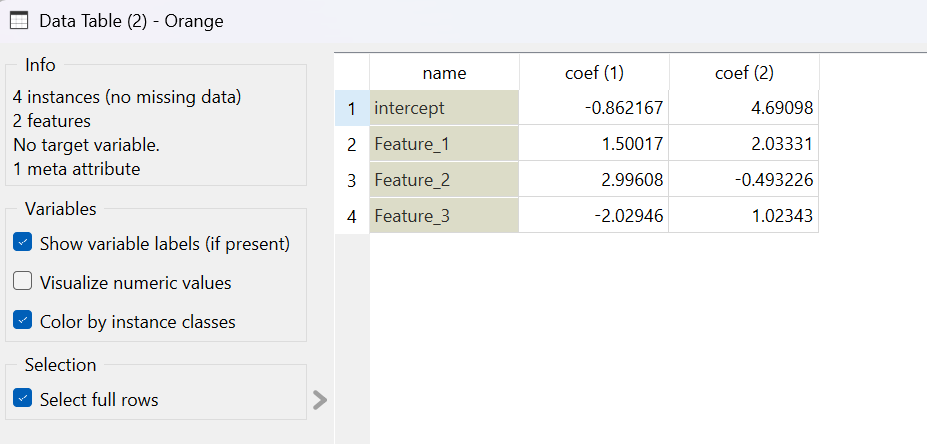